In [1]:
#1.Introduction
#Project Title: Sentiment Analysis on Twitter Data using NLP
#Objective:
#To classify tweets into positive, negative, or neutral sentiments using Natural Language Processing techniques.

In [19]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

In [3]:
#LOAD DATASET
df = pd.read_csv("Tweets.csv")
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [ ]:
#DATA UNDERSTANDING
print(df.shape)
print(df['sentiment'].value_counts())

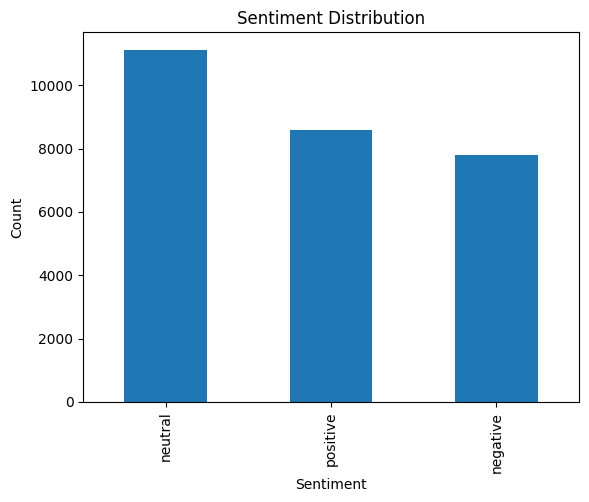

In [4]:
#DATA VISUALIZATION
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [6]:
#TEXT PREPROCESSING
#Text data contains noise such as hashtags, mentions, and URLs. These are removed to improve model performance
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)   # remove links
    text = re.sub(r"@\w+", "", text)      # remove mentions
    text = re.sub(r"#\w+", "", text)      # remove hashtags
    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

df['clean_text'] = df['text'].fillna('').apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
#FEATURE EXTRACTION
#TF-IDF converts text into numerical features for machine learning models
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text']).toarray()
y = df['sentiment']

In [9]:
#TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
#MODEL BUILDING
#Logistic Regression is used for classification of sentiments
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [11]:
#PREDICTION
y_pred = model.predict(X_test)

In [14]:
#EVALUATION
#Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6961979261415318


In [15]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.73      0.60      0.66      1562
     neutral       0.63      0.76      0.69      2230
    positive       0.78      0.70      0.74      1705

    accuracy                           0.70      5497
   macro avg       0.71      0.69      0.70      5497
weighted avg       0.71      0.70      0.70      5497



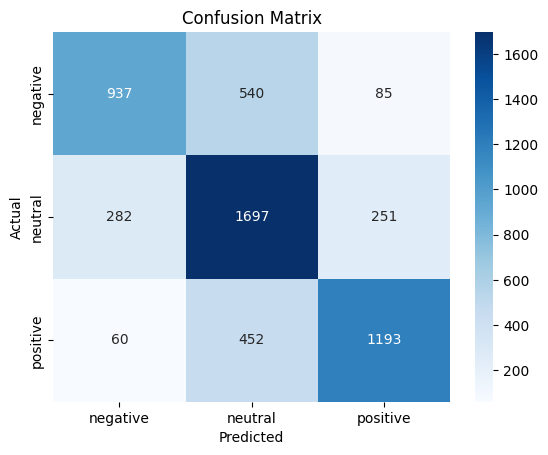

In [20]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
#TEST MODEL
def predict_sentiment(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)
    return prediction[0]

print(predict_sentiment("I love this product!"))
print(predict_sentiment("This is the worst experience ever"))

positive
negative


In [ ]:
#Conclusion
#Sentiment analysis was successfully performed on tweet data using NLP techniques.
#Text preprocessing and TF-IDF helped convert text into numerical form.
#Logistic Regression provided a simple and effective model.
#This approach can be used in real-world applications like customer feedback analysis.